In [ ]:
import sys
from pathlib import Path
import importlib

# 添加根目录到 path 以便导入 plot_functions 和 style
root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_fedgra_learning_curves

from style import MatplotlibStyle

# === 共享配置 ===
LEGEND_MAP = {
    "adafl": "AdaFL", "afl": "AFL", "fedgra": "FedGRA",
    "fedsdr": "FedSDR", "high_loss": "High-Loss",
    "high_weight_divergence": "High-Weight-Div",
    "oort": "Oort", "powd": "Pow-D", "pyramidfl": "PyramidFL",
    "repufl": "RepuFL", "random": "Random",
    "all_participate": "All-Participate",
}

# 统一颜色映射 — 每个算法在所有图中颜色一致
COLOR_MAP = {
    "FedGRA":    "blue",
    "AdaFL":     "red",
    "AFL":       "green",
    "FedSDR":    "orange",
    "Oort":      "purple",
    "Pow-D":     "brown",
    "PyramidFL": "magenta",
    "Random":    "gray",
    "RepuFL":    "cyan",
    "High-Loss": "pink",
    "High-Weight-Div": "olive",
    "All-Participate": "teal",
}

def plot_dataset(directory, title=None,
    # -----------------------------
    # Font size controls
    # -----------------------------
    title_fontsize=22,
    xlabel_fontsize=24,
    xtick_fontsize=20,
    legend_fontsize=18,

    # -----------------------------
    # Figure controls
    # -----------------------------
    figsize=(10, 6),
    dpi=800,
    save_path=None,

    # -----------------------------
    # Line / style controls
    # -----------------------------
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    window_size=1,

    # -----------------------------
    # Axis controls
    # -----------------------------
    y_lim=(0, 1),
    x_range=None,

    # -----------------------------
    # Style control
    # -----------------------------
    use_style=True,          # 是否应用 MatplotlibStyle

    **kwargs,
):
    """一键绘制指定目录的 FedGRA 对比曲线。颜色由 COLOR_MAP 统一分配。

    Parameters
    ----------
    directory : str
        数据目录名 (相对于当前 notebook)。
    title : str or None
        图表标题。

    title_fontsize, xlabel_fontsize : int
        标题 / 轴标签字体大小（x/y 标签共用）。
    xtick_fontsize : int
        轴刻度字体大小（x/y 刻度共用）。
    legend_fontsize : int
        图例字体大小。

    figsize : tuple
        图形尺寸 (宽, 高)。
    dpi : int
        输出分辨率。
    save_path : str or None
        若提供则保存图片到此路径。

    raw_alpha : float
        原始曲线透明度。
    raw_linewidth : float
        原始曲线线宽。
    smooth_linewidth : float
        平滑曲线线宽。
    window_size : int
        滑动窗口大小 (1=不平滑)。

    y_lim : tuple
        y 轴范围 (min, max)。
    x_range : int or None
        x 轴显示范围。

    use_style : bool
        是否应用 MatplotlibStyle 全局样式。
    **kwargs
        传递给 plot_fedgra_learning_curves 的其他参数。
    """
    if use_style:
        MatplotlibStyle().apply()

    params = dict(
        files=f"./{directory}",
        metric="accuracy",
        auto_legend=True,
        legend_map=LEGEND_MAP,
        color_map=COLOR_MAP,
        y_label="Accuracy",
        y_lim=y_lim,
        figsize=figsize,
        window_size=window_size,
        is_legend=True,
        plot_raw=True,
        sort_files=True,
        # Font size controls
        fontsize_title=title_fontsize,
        fontsize_label=xlabel_fontsize,   # plot_fedgra_learning_curves 共用 x/y label fontsize
        fontsize_legend=legend_fontsize,
        fontsize_tick=xtick_fontsize,     # x/y tick 共用
        # Figure / style controls
        dpi=dpi,
        save_path=save_path,
        raw_alpha=raw_alpha,
        raw_linewidth=raw_linewidth,
        smooth_linewidth=smooth_linewidth,
        x_range=x_range,
    )
    params.update(kwargs)
    if title is not None:
        params["title"] = title
    return plot_fedgra_learning_curves(**params)


## CIFAR-10 CNN — FedGRA Method Comparison

Auto-detect methods from CSV filenames in `./cifar10_cnn/`, plot accuracy curves with rolling average.

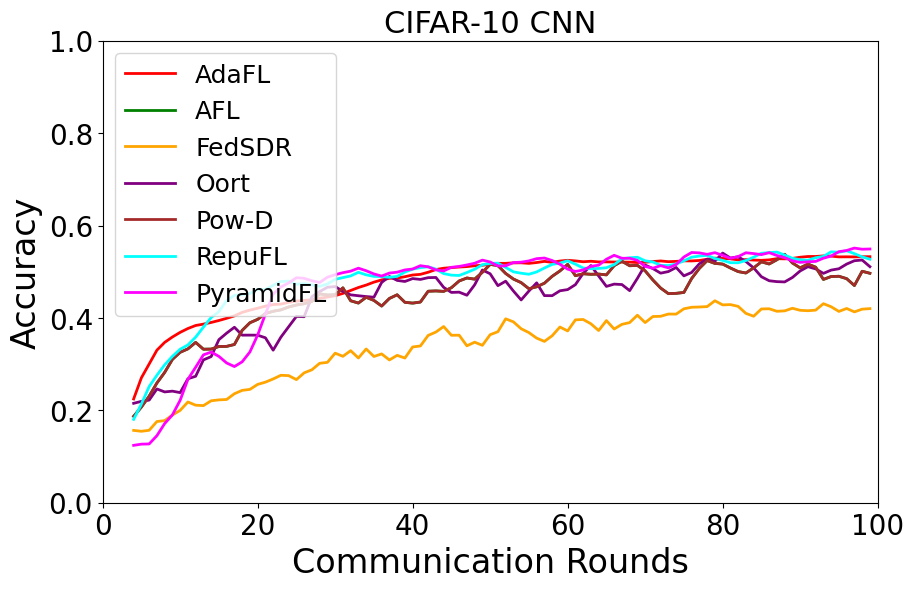

{'AdaFL': 0      0.1049
 1      0.2006
 2      0.2082
 3      0.2896
 4      0.3198
         ...  
 96     0.5338
 97     0.5345
 98     0.5332
 99     0.5313
 100    0.5398
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.1852
 1      0.1780
 2      0.1566
 3      0.2040
 4      0.2114
         ...  
 96     0.4959
 97     0.4755
 98     0.5480
 99     0.4755
 100    0.5795
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.1965
 1      0.1328
 2      0.1025
 3      0.2059
 4      0.1452
         ...  
 96     0.4577
 97     0.3744
 98     0.4609
 99     0.4296
 100    0.4146
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.1736
 1      0.2007
 2      0.1748
 3      0.2362
 4      0.2905
         ...  
 96     0.5406
 97     0.5720
 98     0.4378
 99     0.4666
 100    0.5637
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.1852
 1      0.1780
 2      0.1566
 3      0.2040
 4      0.2114
         ...  
 96     0.4959
 97     

In [3]:
# CIFAR-10 CNN
plot_dataset("cifar10_cnn", title="CIFAR-10 CNN", x_range=100)

## FMNIST

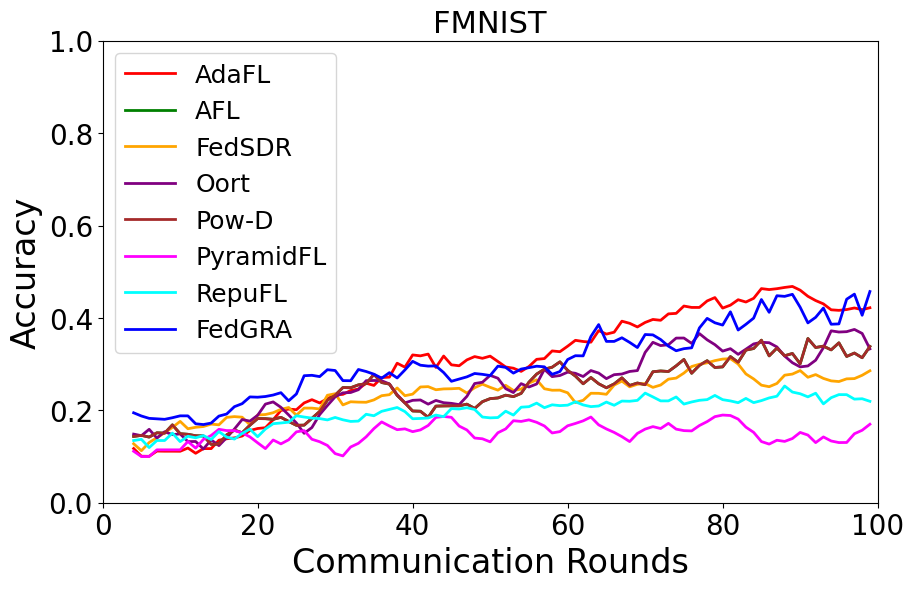

{'AdaFL': 0      0.1839
 1      0.1013
 2      0.1000
 3      0.1013
 4      0.1000
         ...  
 96     0.3876
 97     0.4448
 98     0.4093
 99     0.4361
 100    0.4064
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.1842
 1      0.1251
 2      0.1145
 3      0.1928
 4      0.1009
         ...  
 96     0.3249
 97     0.3183
 98     0.2850
 99     0.4307
 100    0.4889
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.1839
 1      0.1006
 2      0.1322
 3      0.1164
 4      0.1050
         ...  
 96     0.2521
 97     0.3069
 98     0.2917
 99     0.2939
 100    0.2444
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.1961
 1      0.1202
 2      0.1945
 3      0.1002
 4      0.1315
         ...  
 96     0.3510
 97     0.3640
 98     0.3245
 99     0.3075
 100    0.2983
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.1842
 1      0.1251
 2      0.1145
 3      0.1928
 4      0.1009
         ...  
 96     0.3249
 97     

In [4]:
# FMNIST
plot_dataset("fmnist", title="FMNIST", x_range=100)

## IMDB (TinyBERT) — 100 rounds


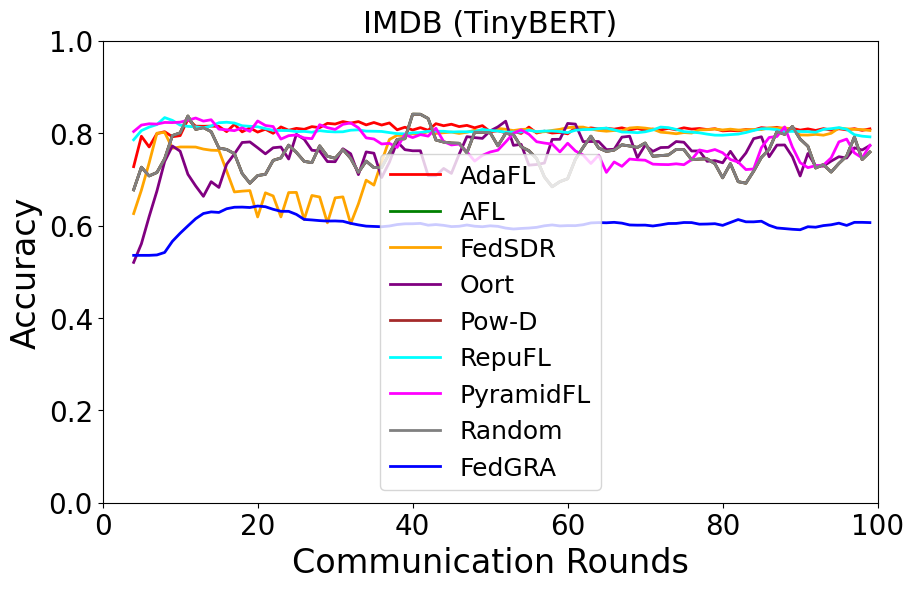

{'AdaFL': 0      0.50380
 1      0.78236
 2      0.69448
 3      0.82272
 4      0.83384
         ...   
 96     0.80496
 97     0.81484
 98     0.79740
 99     0.81432
 100    0.79920
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.57016
 1      0.75576
 2      0.79456
 3      0.68000
 4      0.58592
         ...   
 96     0.82520
 97     0.79172
 98     0.57424
 99     0.82172
 100    0.81140
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.57380
 1      0.50000
 2      0.51144
 3      0.79764
 4      0.74620
         ...   
 96     0.80596
 97     0.80252
 98     0.80876
 99     0.80828
 100    0.80836
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.54356
 1      0.52496
 2      0.51884
 3      0.50824
 4      0.50548
         ...   
 96     0.80920
 97     0.79700
 98     0.80412
 99     0.80008
 100    0.59716
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.57016
 1      0.75576
 2      0.79456
 3      0.68000
 4   

In [5]:
# IMDB TinyBERT
plot_dataset("imdb_tinybert", title="IMDB (TinyBERT)", x_range=100)


## KMNIST — 100 rounds


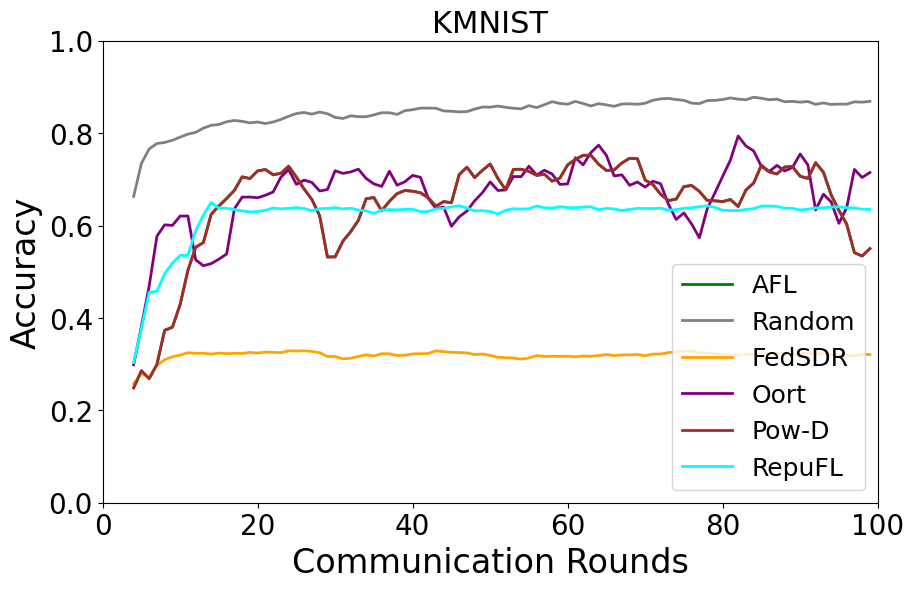

{'AFL': 0      0.1921
 1      0.2824
 2      0.2607
 3      0.1163
 4      0.3915
         ...  
 96     0.4499
 97     0.4162
 98     0.6744
 99     0.5937
 100    0.6820
 Name: accuracy, Length: 101, dtype: float64,
 'Random': 0      0.4264
 1      0.6144
 2      0.7320
 3      0.7650
 4      0.7773
         ...  
 96     0.8643
 97     0.8722
 98     0.8740
 99     0.8730
 100    0.8744
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.1940
 1      0.3387
 2      0.1966
 3      0.2661
 4      0.2939
         ...  
 96     0.3211
 97     0.3173
 98     0.3364
 99     0.3179
 100    0.3162
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.1230
 1      0.1940
 2      0.1360
 3      0.4302
 4      0.6099
         ...  
 96     0.7720
 97     0.7871
 98     0.6934
 99     0.7288
 100    0.6652
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.1921
 1      0.2824
 2      0.2607
 3      0.1163
 4      0.3916
         ...  
 96     0.4499
 97    

In [6]:
# KMNIST
plot_dataset("kmnist", title="KMNIST", x_range=100)


## MNIST — 100 rounds


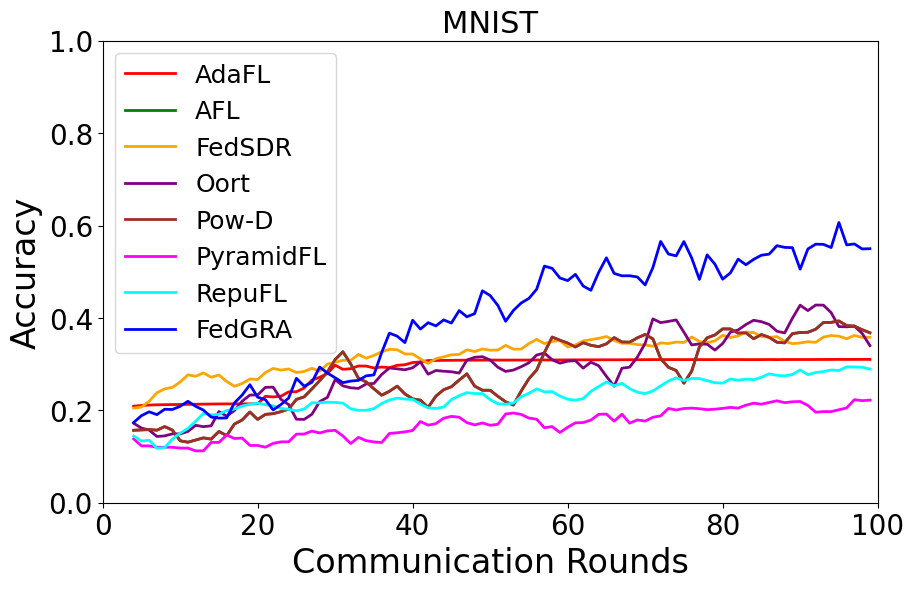

{'AdaFL': 0      0.2040
 1      0.2080
 2      0.2098
 3      0.2113
 4      0.2116
         ...  
 96     0.3097
 97     0.3104
 98     0.3107
 99     0.3097
 100    0.3102
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.2091
 1      0.1945
 2      0.1085
 3      0.1155
 4      0.1564
         ...  
 96     0.3527
 97     0.3470
 98     0.3620
 99     0.3636
 100    0.5132
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.2090
 1      0.1495
 2      0.1916
 3      0.2108
 4      0.2621
         ...  
 96     0.3387
 97     0.3827
 98     0.3655
 99     0.3631
 100    0.3406
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.1552
 1      0.1936
 2      0.1665
 3      0.1787
 4      0.1660
         ...  
 96     0.3696
 97     0.4187
 98     0.3184
 99     0.3027
 100    0.3520
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.2091
 1      0.1945
 2      0.1085
 3      0.1155
 4      0.1564
         ...  
 96     0.3527
 97     

In [7]:
# MNIST
plot_dataset("mnist", title="MNIST", x_range=100)


## QMNIST — 100 rounds


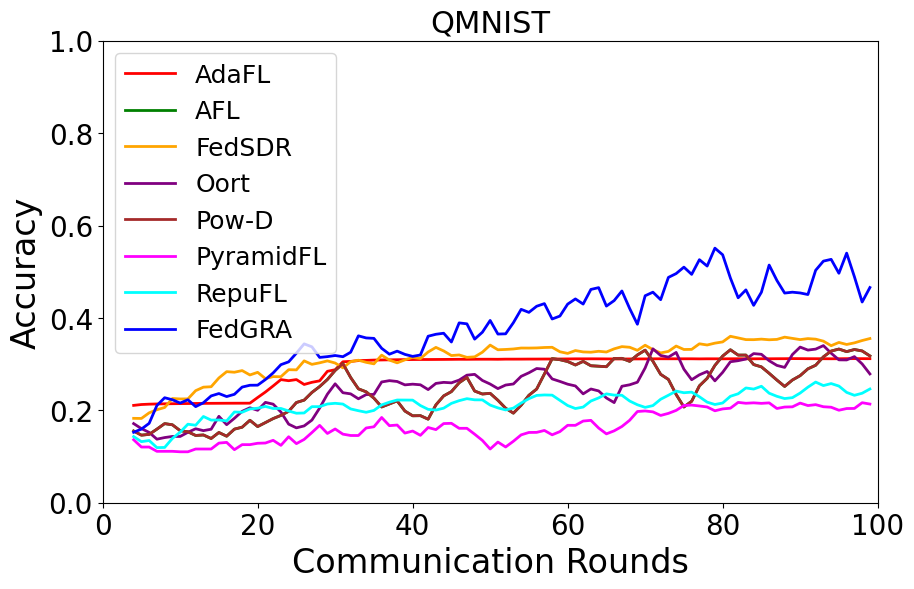

{'AdaFL': 0      0.204517
 1      0.210383
 2      0.212083
 3      0.212917
 4      0.213533
          ...   
 96     0.311850
 97     0.312067
 98     0.311483
 99     0.311650
 100    0.311600
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.209067
 1      0.191767
 2      0.110750
 3      0.114217
 4      0.150067
          ...   
 96     0.323350
 97     0.304683
 98     0.282583
 99     0.310017
 100    0.410667
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.208883
 1      0.150617
 2      0.166683
 3      0.205917
 4      0.181117
          ...   
 96     0.358183
 97     0.365167
 98     0.353100
 99     0.329033
 100    0.333000
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.154650
 1      0.194217
 2      0.171417
 3      0.171150
 4      0.164850
          ...   
 96     0.306833
 97     0.363367
 98     0.251183
 99     0.223083
 100    0.342800
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.209067
 1      

In [8]:
# QMNIST
plot_dataset("qmnist", title="QMNIST", x_range=100)


## SST-2 (TinyBERT) — 100 rounds


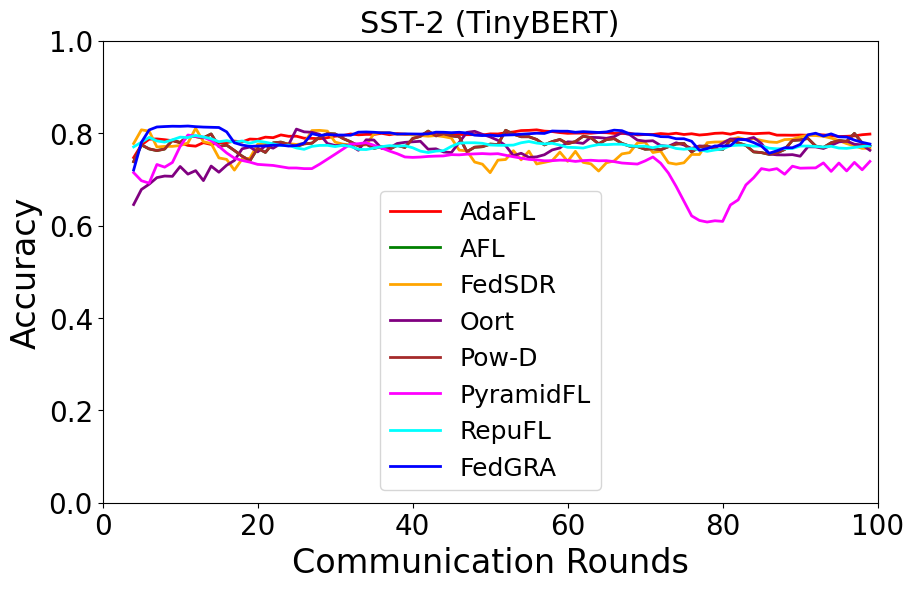

{'AdaFL': 0      0.655963
 1      0.741972
 2      0.780963
 3      0.754587
 4      0.801606
          ...   
 96     0.795872
 97     0.802752
 98     0.800459
 99     0.800459
 100    0.797018
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.625000
 1      0.787844
 2      0.795872
 3      0.795872
 4      0.686927
          ...   
 96     0.791284
 97     0.797018
 98     0.686927
 99     0.777523
 100    0.750000
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.654817
 1      0.800459
 2      0.806193
 3      0.808486
 4      0.817661
          ...   
 96     0.763761
 97     0.764908
 98     0.761468
 99     0.777523
 100    0.777523
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.513761
 1      0.697248
 2      0.659404
 3      0.731651
 4      0.625000
          ...   
 96     0.803899
 97     0.736239
 98     0.754587
 99     0.755734
 100    0.716743
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.625000
 1      

In [9]:
# SST-2 TinyBERT
plot_dataset("sst2", title="SST-2 (TinyBERT)", x_range=100)


## SVHN VGG — 100 rounds


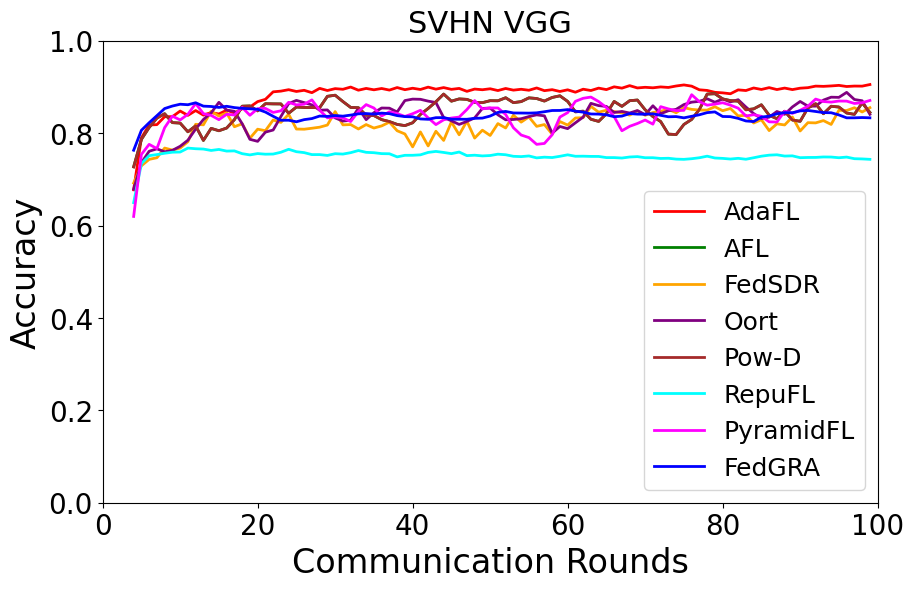

{'AdaFL': 0      0.239052
 1      0.727835
 2      0.800054
 3      0.772242
 4      0.846958
          ...   
 96     0.897549
 97     0.905655
 98     0.903388
 99     0.911647
 100    0.907959
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.577174
 1      0.748809
 2      0.637561
 3      0.835472
 4      0.835817
          ...   
 96     0.827021
 97     0.869315
 98     0.868009
 99     0.783305
 100    0.842770
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.619584
 1      0.688844
 2      0.659534
 3      0.748771
 4      0.743239
          ...   
 96     0.840158
 97     0.871043
 98     0.824985
 99     0.874155
 100    0.805432
 Name: accuracy, Length: 101, dtype: float64,
 'Oort': 0      0.432929
 1      0.678242
 2      0.729448
 3      0.745390
 4      0.808274
          ...   
 96     0.891403
 97     0.819645
 98     0.833820
 99     0.762907
 100    0.897933
 Name: accuracy, Length: 101, dtype: float64,
 'Pow-D': 0      0.577174
 1      

In [10]:
# SVHN VGG
plot_dataset("svhn_vgg", title="SVHN VGG", x_range=100)


## AWS MNIST — 100 rounds

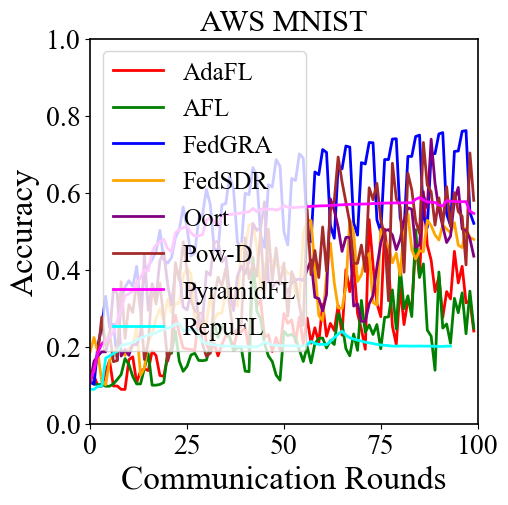

{'AdaFL': 0      0.1135
 1      0.1241
 2      0.0974
 3      0.0974
 4      0.1342
         ...  
 96     0.4089
 97     0.3139
 98     0.3195
 99     0.2409
 100    0.1135
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0     0.1132
 1     0.1036
 2     0.1011
 3     0.1025
 4     0.0974
        ...  
 95    0.2884
 96    0.3400
 97    0.2337
 98    0.3445
 99    0.2482
 Name: accuracy, Length: 100, dtype: float64,
 'FedGRA': 0     0.1078
 1     0.1023
 2     0.2032
 3     0.2525
 4     0.3310
        ...  
 95    0.7084
 96    0.7595
 97    0.7614
 98    0.5490
 99    0.5204
 Name: accuracy, Length: 100, dtype: float64,
 'FedSDR': 0      0.1872
 1      0.2238
 2      0.1852
 3      0.1072
 4      0.1008
         ...  
 98     0.4838
 99     0.4789
 100    0.4745
 101    0.4640
 102    0.4577
 Name: accuracy, Length: 103, dtype: float64,
 'Oort': 0     0.1068
 1     0.1624
 2     0.1765
 3     0.1868
 4     0.1868
        ...  
 95    0.6137
 96    0.5057
 97    0.5020
 98    0

In [6]:
# AWS MNIST
plot_dataset("aws/mnist", title="AWS MNIST", x_range=100, header=0, auto_legend=False,
    labels=["adafl", "afl", "fedgra", "fedsdr", "oort", "powd", "pyramidfl", "repufl"], figsize=(5,5))

## AWS FMNIST — 100 rounds

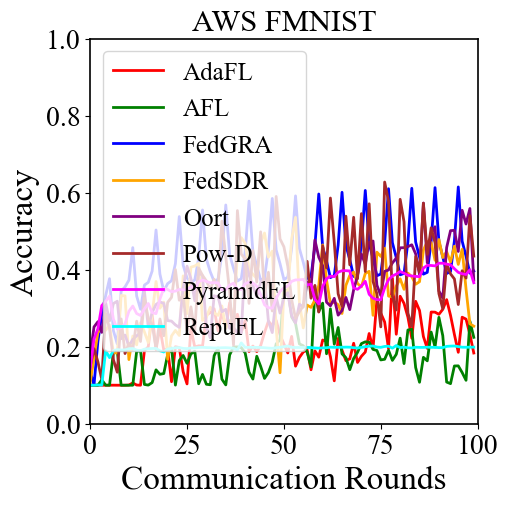

{'AdaFL': 0     0.1000
 1     0.1000
 2     0.1000
 3     0.1000
 4     0.1000
        ...  
 95    0.1855
 96    0.2767
 97    0.2717
 98    0.2320
 99    0.1837
 Name: accuracy, Length: 100, dtype: float64,
 'AFL': 0     0.1000
 1     0.1000
 2     0.1000
 3     0.1139
 4     0.1001
        ...  
 95    0.1503
 96    0.1330
 97    0.1128
 98    0.2663
 99    0.2244
 Name: accuracy, Length: 100, dtype: float64,
 'FedGRA': 0     0.1346
 1     0.1014
 2     0.2140
 3     0.2849
 4     0.3328
        ...  
 95    0.6150
 96    0.4743
 97    0.4350
 98    0.3910
 99    0.3965
 Name: accuracy, Length: 100, dtype: float64,
 'FedSDR': 0     0.1073
 1     0.1702
 2     0.2375
 3     0.2466
 4     0.2426
        ...  
 95    0.4138
 96    0.4531
 97    0.3499
 98    0.2595
 99    0.2534
 Name: accuracy, Length: 100, dtype: float64,
 'Oort': 0     0.1794
 1     0.2514
 2     0.2650
 3     0.2373
 4     0.3137
        ...  
 95    0.4474
 96    0.5543
 97    0.5187
 98    0.5590
 99    0.3730
 N

In [5]:
# AWS FMNIST
plot_dataset("aws/fmnist", title="AWS FMNIST", x_range=100, header=0, auto_legend=False,
    labels=["adafl", "afl", "fedgra", "fedsdr", "oort", "powd", "pyramidfl", "repufl"], figsize=(5,5))